# Simulation der Positionen weißer Kugeln

Eine Urne enthält $w$ weiße und $s$ schwarze Kugeln. Alle $N=w+s$ Kugeln werden ohne Zurücklegen gezogen. Die Zufallsgröße $T_j$ bezeichnet die Position der $j$-ten weißen Kugel.

Für die erwartete Position gilt exakt

$$
E(T_j)=\frac{j(N+1)}{w+1}, \qquad j=1,\ldots,w.
$$

Die Simulation stellt den exakten Erwartungswert den empirischen Kenngrößen

$$
\widehat E(T_j),\qquad \widehat V(T_j),\qquad \widehat\sigma(T_j)
$$

gegenüber. Damit wird nicht nur die Lage, sondern auch die Streuung der zufälligen Positionen sichtbar.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Eingaben

Die Voreinstellung $w=2$ und $s=3$ gehört zum Ankerbeispiel. Für andere Urneninhalte müssen nur die folgenden Werte geändert werden.

In [9]:
w = 20
s = 30

anzahl_simulationen = 100_000
seed = 42

## Simulation und Berechnung

In jedem Durchgang wird eine Weiß-Schwarz-Folge zufällig angeordnet. Anschließend werden die Positionen aller weißen Kugeln gespeichert.

Die empirische Varianz wird mit dem Nenner $M$ berechnet, wobei $M$ die Anzahl der Simulationen ist:

$$
\widehat V(T_j)=\frac{1}{M}\sum_{r=1}^M\left(T_j^{(r)}-\widehat E(T_j)\right)^2.
$$

In [10]:
def simuliere_positionen(w, s, anzahl_simulationen, seed):
    """Simuliert die Positionen T_1, ..., T_w."""
    if not isinstance(w, (int, np.integer)) or w < 1:
        raise ValueError("w muss eine positive ganze Zahl sein.")
    if not isinstance(s, (int, np.integer)) or s < 0:
        raise ValueError("s muss eine nichtnegative ganze Zahl sein.")
    if not isinstance(anzahl_simulationen, (int, np.integer)) or anzahl_simulationen < 1:
        raise ValueError("anzahl_simulationen muss eine positive ganze Zahl sein.")

    rng = np.random.default_rng(seed)
    grundfolge = np.array([1] * w + [0] * s, dtype=np.int8)
    positionen = np.empty((anzahl_simulationen, w), dtype=int)

    for durchgang in range(anzahl_simulationen):
        folge = rng.permutation(grundfolge)
        positionen[durchgang] = np.flatnonzero(folge == 1) + 1

    return positionen


def berechne_kenngroessen(positionen, s):
    """Berechnet empirische Kenngrößen und die exakten Erwartungswerte."""
    w = positionen.shape[1]
    N = w + s
    j = np.arange(1, w + 1)

    emp_erwartungswert = positionen.mean(axis=0)
    emp_varianz = ((positionen - emp_erwartungswert) ** 2).mean(axis=0)
    emp_standardabweichung = np.sqrt(emp_varianz)
    exakter_erwartungswert = j * (N + 1) / (w + 1)

    return pd.DataFrame(
        {
            "j": j,
            "emp. E(T_j)": emp_erwartungswert,
            "exakt E(T_j)": exakter_erwartungswert,
            "emp. V(T_j)": emp_varianz,
            "emp. sigma(T_j)": emp_standardabweichung,
        }
    )


def zeichne_positionen(kenngroessen, N):
    """Zeigt empirische Mittelwerte, Standardabweichungen und exakte Mittelwerte."""
    j = kenngroessen["j"].to_numpy()
    emp_erwartungswert = kenngroessen["emp. E(T_j)"].to_numpy()
    emp_standardabweichung = kenngroessen["emp. sigma(T_j)"].to_numpy()
    exakter_erwartungswert = kenngroessen["exakt E(T_j)"].to_numpy()

    fig, ax = plt.subplots(figsize=(8.0, 5.2))
    ax.plot(j, exakter_erwartungswert, color="black", linewidth=1.5, zorder=1)
    ax.errorbar(
        j,
        emp_erwartungswert,
        yerr=emp_standardabweichung,
        fmt="o",
        color="tab:blue",
        ecolor="tab:blue",
        elinewidth=2.0,
        capsize=5,
        markersize=6,
        zorder=2,
    )

    ax.set_xlabel(r"$j$")
    ax.set_ylabel("Position")
    ax.set_xticks(j)
    ax.set_xlim(0.5, len(j) + 0.5)
    ax.set_ylim(0.5, N + 0.5)
    ax.grid(axis="y", color="0.85", linewidth=0.8)

    fig.text(
        0.5,
        0.025,
        "Schwarze Linie: exakte Erwartungswerte.  "
        "Blaue Punkte und Strecken: empirische Mittelwerte ± eine empirische Standardabweichung.",
        ha="center",
        va="bottom",
        fontsize=9,
    )
    fig.tight_layout(rect=(0, 0.10, 1, 1))
    return fig, ax


def pruefe_spiegelsymmetrie(kenngroessen, N):
    """Vergleicht T_j mit der gespiegelten Position T_(w+1-j)."""
    w = len(kenngroessen)
    zeilen = []

    for j in range(1, (w + 1) // 2 + 1):
        k = w + 1 - j
        e_summe = (
            kenngroessen.loc[j - 1, "emp. E(T_j)"]
            + kenngroessen.loc[k - 1, "emp. E(T_j)"]
        )
        v_differenz = abs(
            kenngroessen.loc[j - 1, "emp. V(T_j)"]
            - kenngroessen.loc[k - 1, "emp. V(T_j)"]
        )
        zeilen.append(
            {
                "j": j,
                "w+1-j": k,
                "emp. E(T_j) + emp. E(T_(w+1-j))": e_summe,
                "N+1": N + 1,
                "Betrag der Differenz der emp. Varianzen": v_differenz,
            }
        )

    return pd.DataFrame(zeilen)

In [11]:
N = w + s
positionen = simuliere_positionen(w, s, anzahl_simulationen, seed)
kenngroessen = berechne_kenngroessen(positionen, s)

## Empirische Kenngrößen

In [12]:
kenngroessen.set_index("j").round(4)

,emp. E(T_j),exakt E(T_j),emp. V(T_j),emp. sigma(T_j)
j,,,,
1,2.4348,2.4286,3.2124,1.7923
2,4.8752,4.8571,6.0541,2.4605
3,7.2982,7.2857,8.5317,2.9209
4,9.7314,9.7143,10.7325,3.2760
5,12.1605,12.1429,12.5850,3.5475
6,14.5997,14.5714,14.1339,3.7595
7,17.0228,17.0000,15.3952,3.9237
8,19.4435,19.4286,16.3291,4.0409
9,21.8613,21.8571,16.9473,4.1167


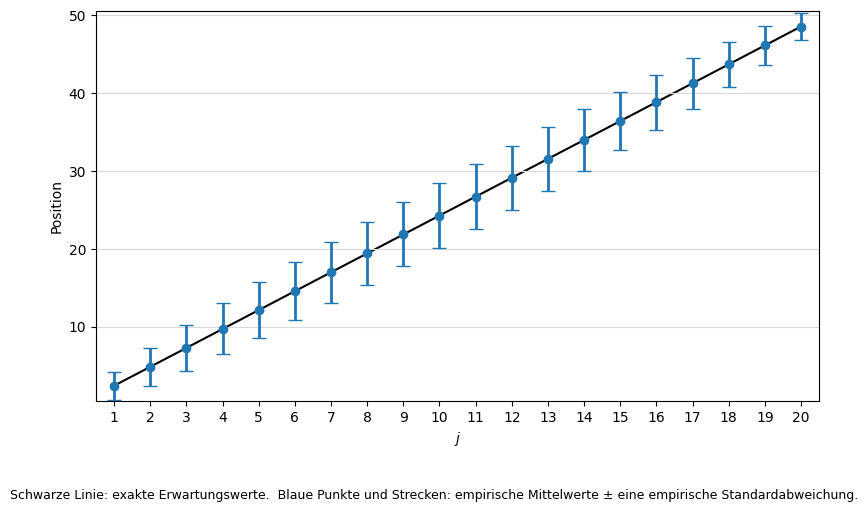

In [13]:
fig, ax = zeichne_positionen(kenngroessen, N)
plt.show()

**Wichtig:** Die blauen Strecken sind keine Konfidenzintervalle. Sie zeigen lediglich die Streuung der simulierten Positionen durch eine empirische Standardabweichung nach unten und oben. Sie sind auch nicht als Intervalle mit einem bestimmten Wahrscheinlichkeitsinhalt zu verstehen.

## Empirische Spiegelsymmetrie

Aus

$$
T_j\stackrel{\mathrm d}{=}N+1-T_{w+1-j}
$$

folgen

$$
E(T_j)+E(T_{w+1-j})=N+1
$$

und

$$
V(T_j)=V(T_{w+1-j}).
$$

Die Simulation macht beide Beziehungen näherungsweise sichtbar.

In [14]:
symmetrie = pruefe_spiegelsymmetrie(kenngroessen, N)
symmetrie.set_index(["j", "w+1-j"]).round(4)

,,emp. E(T_j) + emp. E(T_(w+1-j)),N+1,Betrag der Differenz der emp. Varianzen
j,w+1-j,,,
1,20,51.0023,51,0.0196
2,19,51.0131,51,0.0581
3,18,51.0003,51,0.0209
4,17,51.0066,51,0.0152
5,16,51.0075,51,0.0056
6,15,51.0126,51,0.0386
7,14,51.0079,51,0.0259
8,13,50.9945,51,0.0980
9,12,50.9922,51,0.0105


Die exakte Varianz lässt sich ebenfalls bestimmen. Ihre Herleitung wird hier bewusst nicht benötigt: Die Simulation übernimmt eine eigenständige Erkenntnisfunktion, indem sie zeigt, wie unterschiedlich die zufälligen Positionen trotz klar bestimmter Erwartungswerte ausfallen können.